# DenseNet Baseline + Class Weighting

- DenseNet121, no pretrained weights
- Simple linear classifier head
- **pos_weight** added to BCEWithLogitsLoss to handle class imbalance
- Adam optimizer

### 1. Import Libraries

In [1]:
import sys
import os
from pathlib import Path

# Find project root regardless of CWD (works in VS Code, Jupyter Lab, etc.)
ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

from src.data.dataloader import get_dataloaders
from src.models.densenet_baseline import DenseNetBaseline
from src.training.trainer import train_one_epoch, validate_one_epoch

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

os.chdir(ROOT)
print(Path.cwd())

c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning


### 2. Use Cuda else MPS

In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


### 3. Load dataset

- Use DenseNetBaselineWeighted model
- Compute pos_weight from train CSV: num_non_melanoma / num_melanoma
- Use BCEWithLogitsLoss with pos_weight
- Use Adam optimizer

In [3]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='data_new/splits/train.csv',
    val_csv='data_new/splits/val.csv',
    test_csv='data_new/splits/test.csv',
    image_dir='data_new/images/train',
    test_image_dir='data_new/images/test',
    batch_size=32,
    image_size=224,
    num_workers=0,
)

# Compute class weight from training CSV
train_df = pd.read_csv("data_new/splits/train.csv")
num_neg = (train_df["label"] == 0).sum()    # Non-Melanoma
num_pos = (train_df["label"] == 1).sum()    # Melanoma
pos_weight = torch.tensor([num_neg / num_pos]).to(device)
print(f"Non-Melanoma: {num_neg} | Melanoma: {num_pos} | pos_weight: {pos_weight.item():.3f}")

model = DenseNetBaseline().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Non-Melanoma: 7114 | Melanoma: 877 | pos_weight: 8.112


c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


### 4. Train model

In [4]:
num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_metrics["loss"])
    val_losses.append(val_metrics["loss"])
    train_accuracies.append(train_metrics["accuracy"])
    val_accuracies.append(val_metrics["accuracy"])

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Train Acc: {train_metrics['accuracy']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Val Acc: {val_metrics['accuracy']:.4f}"
    )

Epoch [1/20] | Train Loss: 0.9932, Train Acc: 0.6418 | Val Loss: 0.9613, Val Acc: 0.7490


Epoch [2/20] | Train Loss: 0.9329, Train Acc: 0.6693 | Val Loss: 1.1780, Val Acc: 0.8424


Epoch [3/20] | Train Loss: 0.8866, Train Acc: 0.6970 | Val Loss: 0.9144, Val Acc: 0.6275


Epoch [4/20] | Train Loss: 0.8852, Train Acc: 0.6755 | Val Loss: 0.9169, Val Acc: 0.7129


Epoch [5/20] | Train Loss: 0.8476, Train Acc: 0.7152 | Val Loss: 0.8690, Val Acc: 0.7110


...

Epoch [16/20] | Train Loss: 0.7532, Train Acc: 0.7448 | Val Loss: 0.9347, Val Acc: 0.5963


Epoch [17/20] | Train Loss: 0.7372, Train Acc: 0.7467 | Val Loss: 0.8001, Val Acc: 0.7075


Epoch [18/20] | Train Loss: 0.7371, Train Acc: 0.7540 | Val Loss: 0.8015, Val Acc: 0.6833


Epoch [19/20] | Train Loss: 0.7412, Train Acc: 0.7525 | Val Loss: 0.8593, Val Acc: 0.7564


Epoch [20/20] | Train Loss: 0.7375, Train Acc: 0.7498 | Val Loss: 0.8476, Val Acc: 0.6729


### 5. Plot loss and accuracy curves

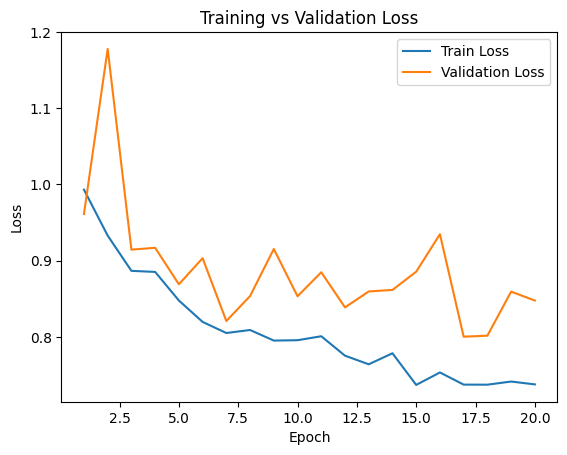

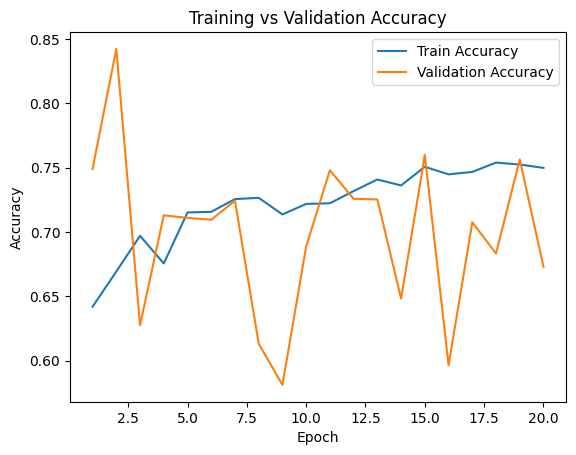

In [5]:
epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

### 6. Evaluate model

[[TN, FP],<br/>
 [FN, TP]]

- TN: correctly predicted non-melanoma
- FP: benign predicted as melanoma
- FN: melanoma missed
- TP: correctly predicted melanoma

Precision → "When the model says YES, how often is it correct?"<br/>
Recall → "Out of all actual YES, how many did we catch?"

In [6]:
model.eval()

all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= 0.5)

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)
print(classification_report(all_labels, all_preds, digits=4))

Confusion Matrix:
[[806 534]
 [ 13 158]]
              precision    recall  f1-score   support

           0     0.9841    0.6015    0.7466      1340
           1     0.2283    0.9240    0.3662       171

    accuracy                         0.6380      1511
   macro avg     0.6062    0.7627    0.5564      1511
weighted avg     0.8986    0.6380    0.7036      1511



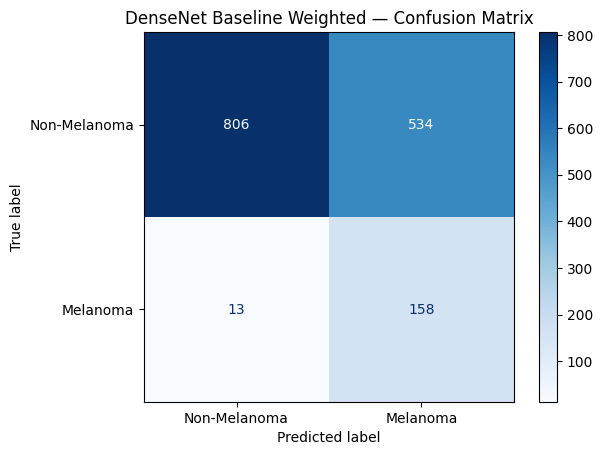

In [7]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Melanoma", "Melanoma"])
disp.plot(cmap="Blues")
plt.title("DenseNet Baseline Weighted — Confusion Matrix")
plt.show()